# CVIP Lab 5: Spatial and Frequency Domain Filtering & Template Matching
**Course:** Computer Vision and Image Processing (CSCS111/CSDS119)  
**Department:** Computer Science and Engineering, SVNIT Surat  

This notebook provides a clean and simple solution for:
- **Part A:** Spatial Domain Filtering, 2D DFT, ILPF, IHPF, GLPF, GHPF, BLPF, and BHPF on the Cameraman image.
- **Part B:** Cross-Correlation Template Matching of a product on a grocery shelf.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Cameraman image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("cameraman.png not found! Place cameraman.png in the current directory.")

print(f"Cameraman image loaded. Shape: {img.shape}")

Cameraman image loaded. Shape: (256, 256)


## Part A.1: Spatial Domain Filtering
We apply **Mean**, **Gaussian**, and **Laplacian** spatial filters to the Cameraman image using neighborhood sizes ($3\times 3, 5\times 5, 9\times 9$).

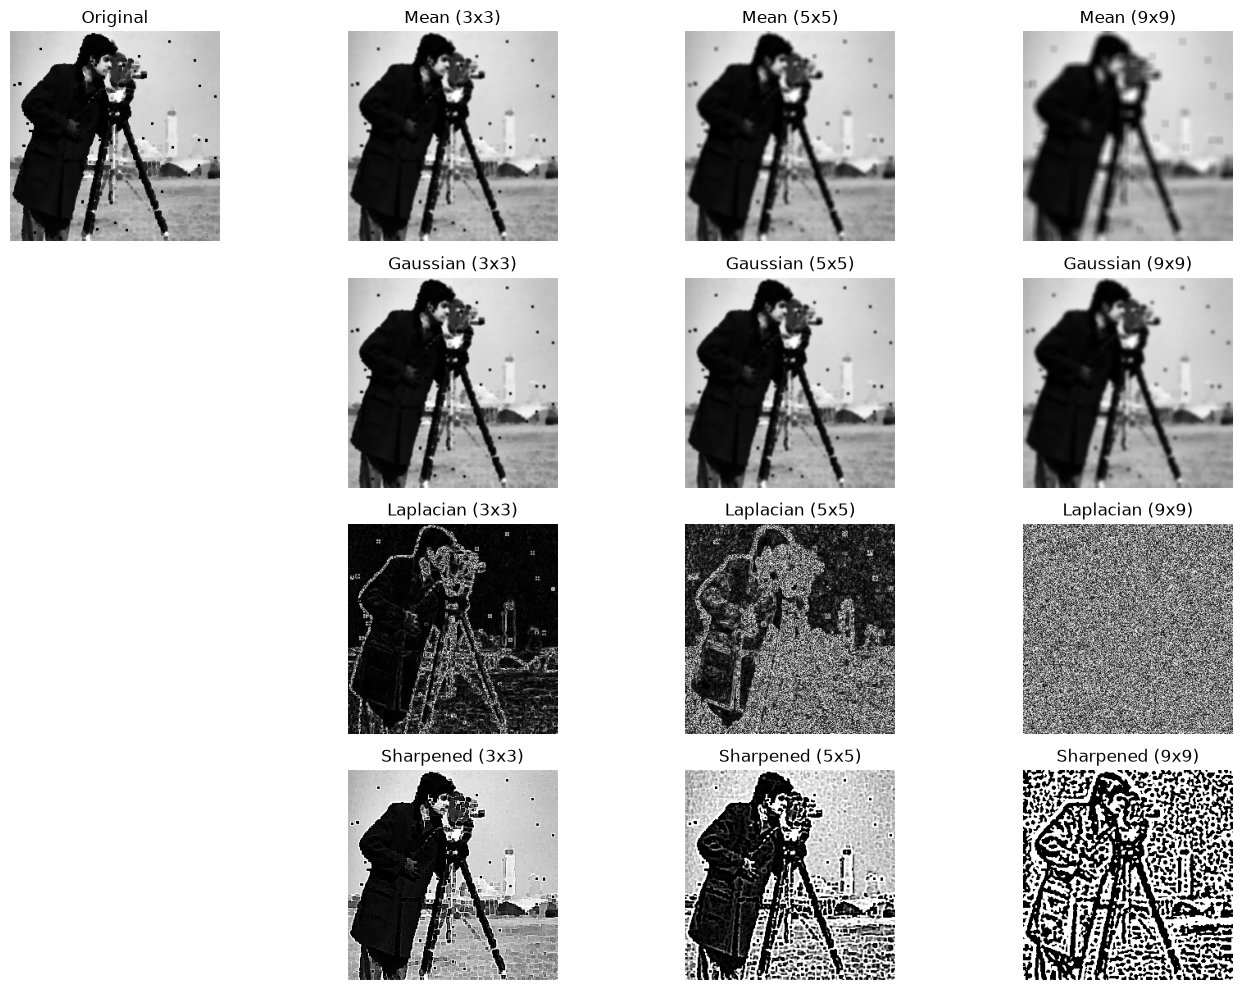

In [2]:
kernel_sizes = [3, 5, 9]

plt.figure(figsize=(14, 10))

# Original Image
plt.subplot(4, len(kernel_sizes) + 1, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

# 1. Mean (Average) Filtering
for i, k in enumerate(kernel_sizes):
    mean_img = cv2.blur(img, (k, k))
    plt.subplot(4, len(kernel_sizes) + 1, i + 2)
    plt.imshow(mean_img, cmap='gray')
    plt.title(f"Mean ({k}x{k})")
    plt.axis('off')

# 2. Gaussian Filtering
for i, k in enumerate(kernel_sizes):
    gauss_img = cv2.GaussianBlur(img, (k, k), sigmaX=0)
    plt.subplot(4, len(kernel_sizes) + 1, len(kernel_sizes) + 2 + i + 1)
    plt.imshow(gauss_img, cmap='gray')
    plt.title(f"Gaussian ({k}x{k})")
    plt.axis('off')

# 3. Laplacian Edge Detection
for i, k in enumerate(kernel_sizes):
    lap_edges = cv2.Laplacian(img, cv2.CV_64F, ksize=k)
    lap_abs = np.uint8(np.absolute(lap_edges))
    plt.subplot(4, len(kernel_sizes) + 1, 2 * (len(kernel_sizes) + 1) + i + 2)
    plt.imshow(lap_abs, cmap='gray')
    plt.title(f"Laplacian ({k}x{k})")
    plt.axis('off')

# 4. Laplacian Sharpened Image
for i, k in enumerate(kernel_sizes):
    lap_edges = cv2.Laplacian(img, cv2.CV_64F, ksize=k)
    sharpened = np.clip(img.astype(np.float64) - 0.5 * lap_edges, 0, 255).astype(np.uint8)
    plt.subplot(4, len(kernel_sizes) + 1, 3 * (len(kernel_sizes) + 1) + i + 2)
    plt.imshow(sharpened, cmap='gray')
    plt.title(f"Sharpened ({k}x{k})")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations (Spatial Domain Filtering):
- **Mean Filter:** Produces uniform local smoothing. As the neighborhood size increases from $3\times 3$ to $9\times 9$, random noise is significantly smoothed, but high-frequency edge details are heavily blurred.
- **Gaussian Filter:** Uses bell-shaped spatial weights centered on each pixel. Compared to the mean filter with identical kernel size, it smooths more naturally while retaining noticeable edge boundaries.
- **Laplacian Filter:** Highlights rate of intensity change (second-order derivative). Larger kernels capture broader edge boundaries but amplify noise. Subtracting the Laplacian enhances edge sharpness.

## Part A.2: Discrete Fourier Transform (DFT)
We compute the 2D DFT of the Cameraman image, visualize its centered magnitude and phase spectra, and reconstruct the spatial image using the Inverse DFT (IDFT).

Reconstruction maximum absolute difference: 1.14e-13


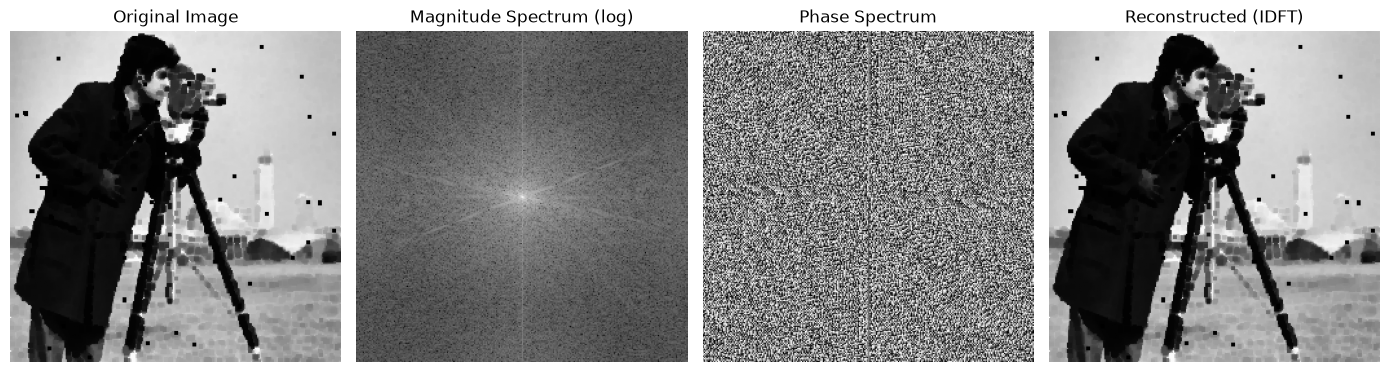

In [3]:
# Compute 2D DFT and shift zero frequency to center
F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)

# Magnitude spectrum (log scale for visual dynamic range) and Phase spectrum
magnitude_spectrum = 20 * np.log(np.abs(F_shift) + 1)
phase_spectrum = np.angle(F_shift)

# Inverse DFT to reconstruct original spatial image
F_ishift = np.fft.ifftshift(F_shift)
img_reconstructed = np.abs(np.fft.ifft2(F_ishift))

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum (log)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(phase_spectrum, cmap='gray')
plt.title("Phase Spectrum")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_reconstructed, cmap='gray')
plt.title("Reconstructed (IDFT)")
plt.axis('off')

plt.tight_layout()
plt.show()

diff = np.max(np.abs(img.astype(float) - img_reconstructed))
print(f"Reconstruction maximum absolute difference: {diff:.2e}")

### Observations (2D DFT):
- **Magnitude Spectrum:** Energy is heavily concentrated around the center (DC and low spatial frequencies representing smooth regions). Star-like patterns correspond to strong vertical and horizontal edges in the scene.
- **Phase Spectrum:** Encodes spatial alignment and geometric structure.
- **Reconstruction:** IDFT recovers the original image with numerical error near zero.

In [4]:
# Helper: Euclidean distance grid D(u, v) from the frequency center
M, N = img.shape
u = np.arange(M) - M / 2
v = np.arange(N) - N / 2
U, V = np.meshgrid(u, v, indexing='ij')
D = np.sqrt(U**2 + V**2)

## Part A.3: Ideal Low-Pass Filter (ILPF)
Defined as:
$$H(u, v) = \begin{cases} 1 & \text{if } D(u, v) \le D_0 \\ 0 & \text{if } D(u, v) > D_0 \end{cases}$$

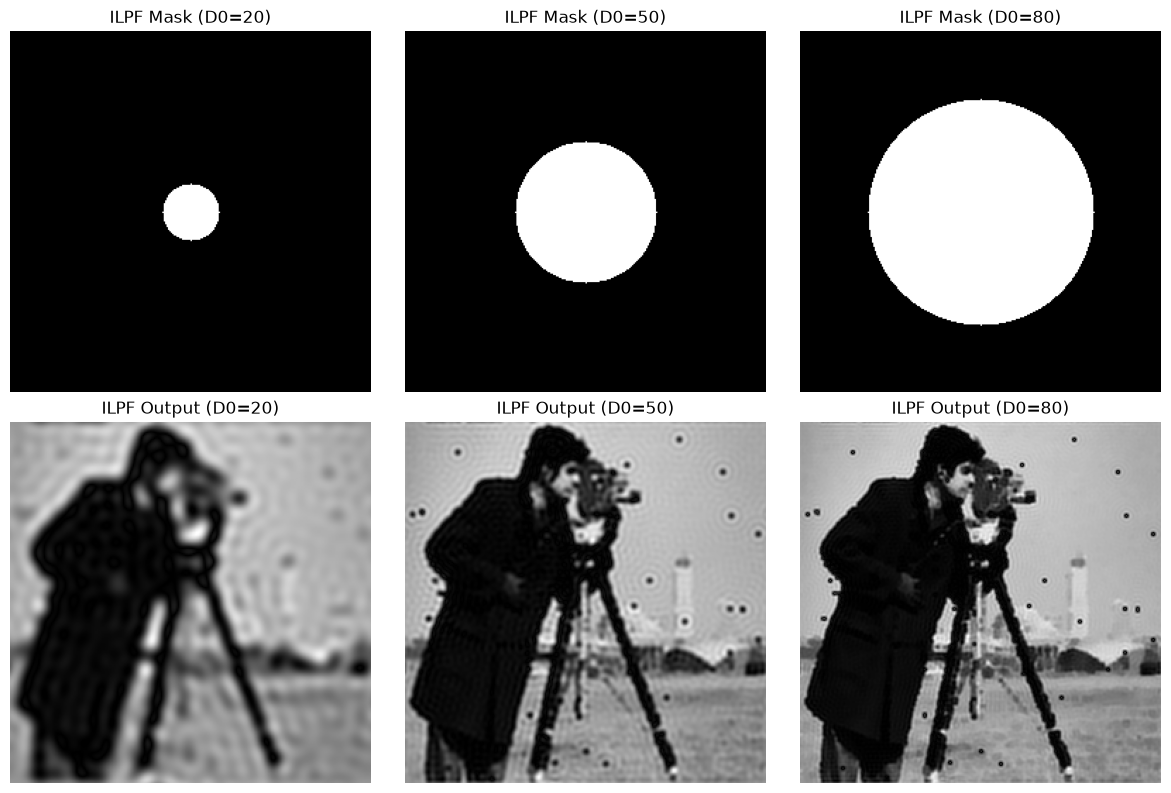

In [5]:
D0_values = [20, 50, 80]

plt.figure(figsize=(12, 8))
for i, D0 in enumerate(D0_values):
    H = (D <= D0).astype(float)
    G = F_shift * H
    filtered_img = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))
    
    plt.subplot(2, len(D0_values), i + 1)
    plt.imshow(H, cmap='gray')
    plt.title(f"ILPF Mask (D0={D0})")
    plt.axis('off')
    
    plt.subplot(2, len(D0_values), len(D0_values) + i + 1)
    plt.imshow(filtered_img, cmap='gray')
    plt.title(f"ILPF Output (D0={D0})")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations (Ideal Low-Pass Filter):
- **Smoothing vs Cutoff:** Smaller $D_0=20$ produces severe blur because most high-frequency edge components are cut off. At $D_0=80$, edges remain much clearer.
- **Ringing Artifacts (Gibbs Phenomenon):** Because the ideal low-pass filter has a sharp discontinuity in the frequency domain, its spatial impulse response is a 2D sinc-like function with side lobes, producing concentric circular ripple/ringing artifacts around sharp edges.

## Part A.4: Ideal High-Pass Filter (IHPF)
Defined as:
$$H(u, v) = \begin{cases} 0 & \text{if } D(u, v) \le D_0 \\ 1 & \text{if } D(u, v) > D_0 \end{cases}$$

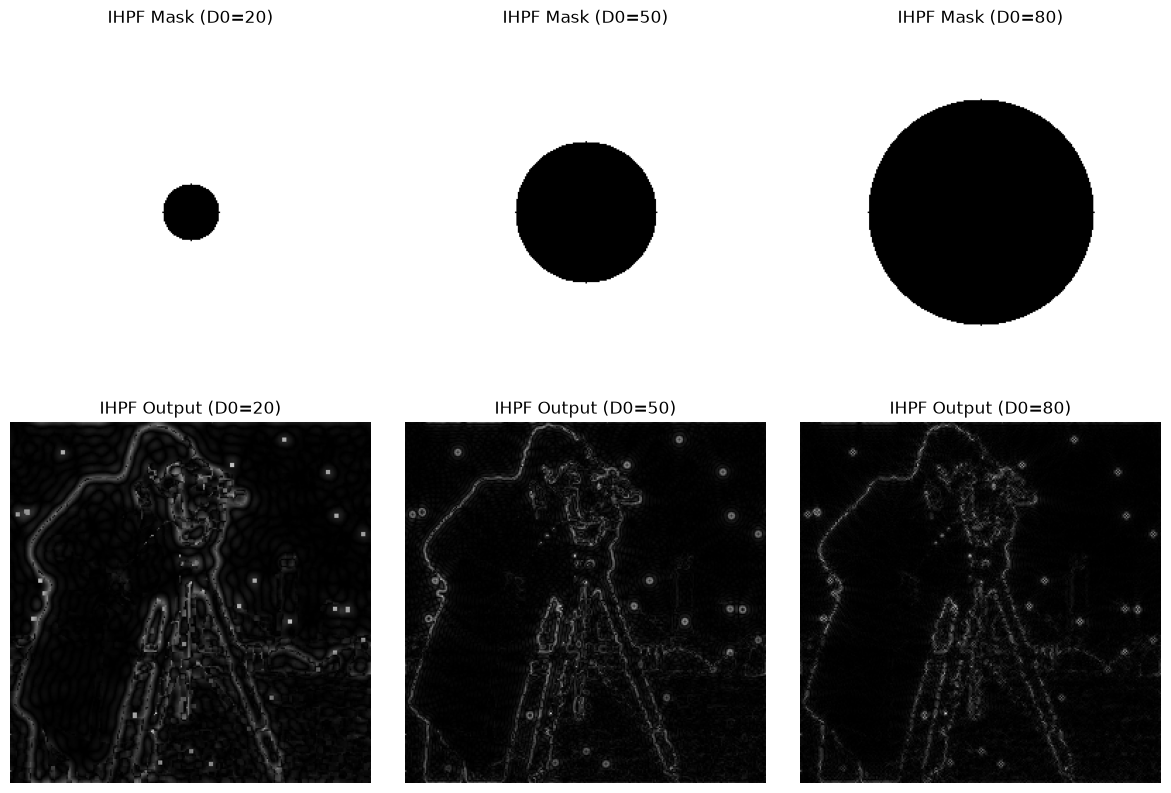

In [6]:
plt.figure(figsize=(12, 8))
for i, D0 in enumerate(D0_values):
    H = (D > D0).astype(float)
    G = F_shift * H
    filtered_img = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))
    
    plt.subplot(2, len(D0_values), i + 1)
    plt.imshow(H, cmap='gray')
    plt.title(f"IHPF Mask (D0={D0})")
    plt.axis('off')
    
    plt.subplot(2, len(D0_values), len(D0_values) + i + 1)
    plt.imshow(filtered_img, cmap='gray')
    plt.title(f"IHPF Output (D0={D0})")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations (Ideal High-Pass Filter):
- **Edge and Detail Enhancement:** Low frequencies (flat background intensities) are removed, leaving isolated boundaries, fine textures, and edges.
- **Cutoff Effect:** Lower $D_0=20$ retains more middle frequencies (broader edge profiles). Higher $D_0=80$ isolates only the finest and sharpest edge transitions.
- **Ringing:** Ringing ripple artifacts are noticeable around high-contrast edges due to the step cutoff.

## Part A.5: Gaussian Low-Pass and High-Pass Filters (GLPF & GHPF)
Transfer functions:
$$H_{GLPF}(u, v) = e^{-\frac{D^2(u, v)}{2 D_0^2}}, \quad H_{GHPF}(u, v) = 1 - H_{GLPF}(u, v)$$

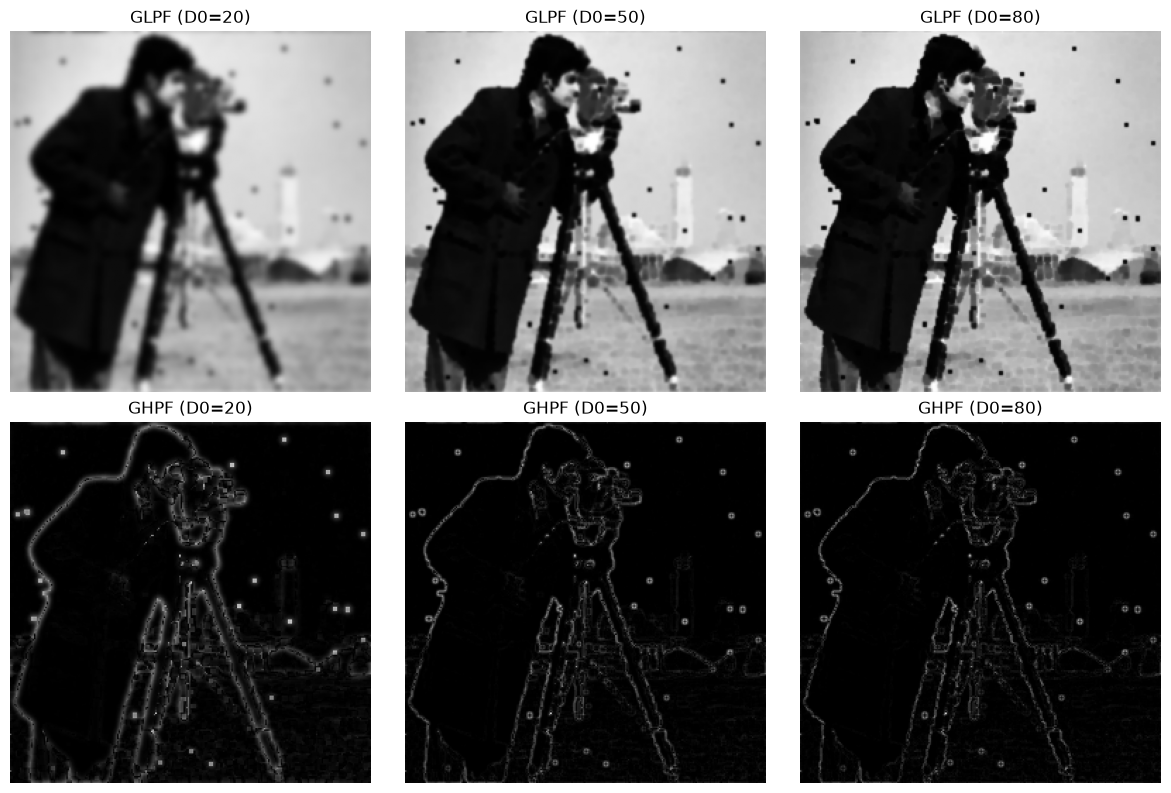

In [7]:
plt.figure(figsize=(12, 8))
for i, D0 in enumerate(D0_values):
    H_lp = np.exp(-(D**2) / (2 * (D0**2)))
    H_hp = 1.0 - H_lp
    
    img_glpf = np.abs(np.fft.ifft2(np.fft.ifftshift(F_shift * H_lp)))
    img_ghpf = np.abs(np.fft.ifft2(np.fft.ifftshift(F_shift * H_hp)))
    
    plt.subplot(2, len(D0_values), i + 1)
    plt.imshow(img_glpf, cmap='gray')
    plt.title(f"GLPF (D0={D0})")
    plt.axis('off')
    
    plt.subplot(2, len(D0_values), len(D0_values) + i + 1)
    plt.imshow(img_ghpf, cmap='gray')
    plt.title(f"GHPF (D0={D0})")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations (Gaussian Filters vs. Ideal Filters):
- **Zero Ringing:** The Fourier transform of a Gaussian is also Gaussian; it contains no negative side lobes in spatial domain. Hence, GLPF and GHPF exhibit **no ringing artifacts whatsoever**.
- **Visual Quality:** Smoothness and high-pass edge transitions look much more natural than the ideal filter equivalents.

## Part A.6: Butterworth Low-Pass and High-Pass Filters (BLPF & BHPF)
Transfer functions with filter order $n$:
$$H_{BLPF}(u, v) = \frac{1}{1 + \left[\frac{D(u, v)}{D_0}\right]^{2n}}, \quad H_{BHPF}(u, v) = \frac{1}{1 + \left[\frac{D_0}{D(u, v) + \epsilon}\right]^{2n}}$$

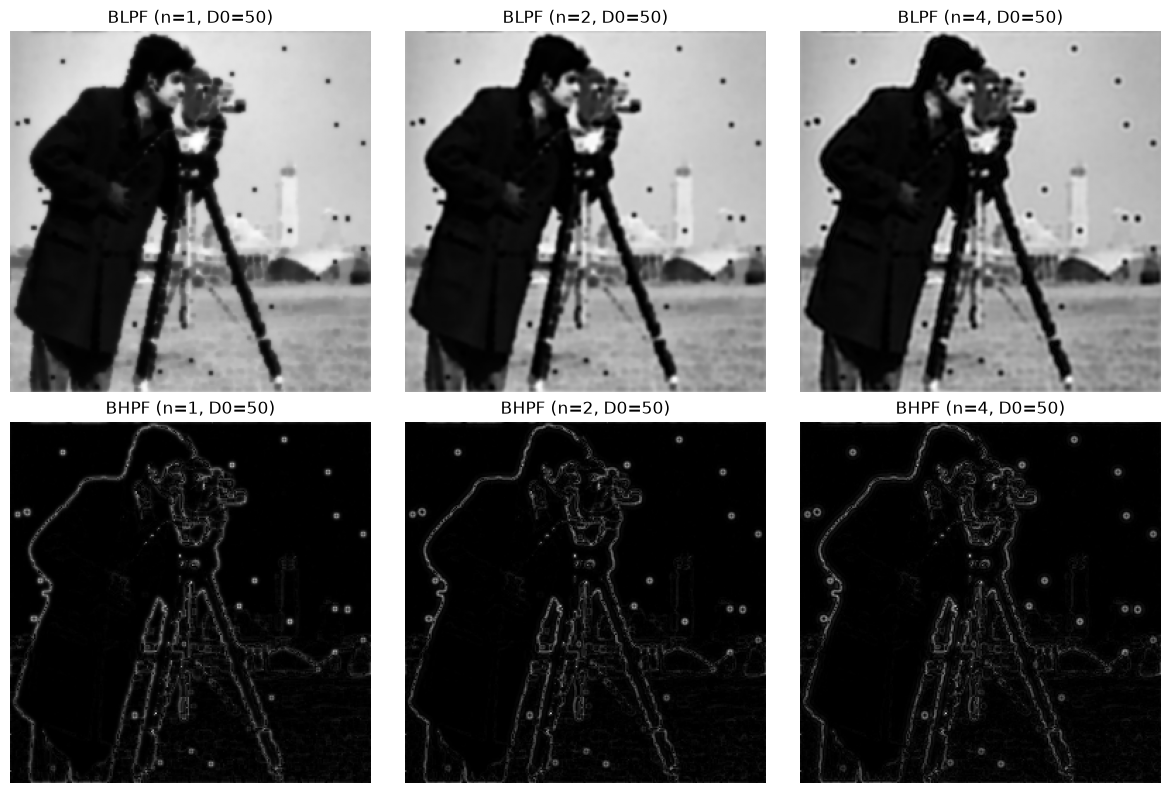

In [8]:
orders = [1, 2, 4]
fixed_D0 = 50

plt.figure(figsize=(12, 8))
for i, n in enumerate(orders):
    H_lp = 1.0 / (1.0 + (D / fixed_D0)**(2 * n))
    H_hp = 1.0 / (1.0 + (fixed_D0 / (D + 1e-6))**(2 * n))
    
    img_blpf = np.abs(np.fft.ifft2(np.fft.ifftshift(F_shift * H_lp)))
    img_bhpf = np.abs(np.fft.ifft2(np.fft.ifftshift(F_shift * H_hp)))
    
    plt.subplot(2, len(orders), i + 1)
    plt.imshow(img_blpf, cmap='gray')
    plt.title(f"BLPF (n={n}, D0={fixed_D0})")
    plt.axis('off')
    
    plt.subplot(2, len(orders), len(orders) + i + 1)
    plt.imshow(img_bhpf, cmap='gray')
    plt.title(f"BHPF (n={n}, D0={fixed_D0})")
    plt.axis('off')

plt.tight_layout()
plt.show()

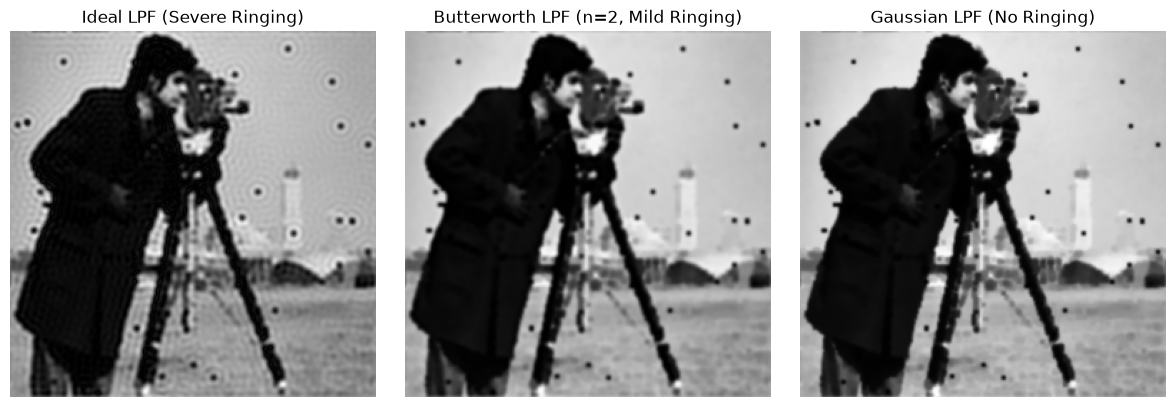

In [9]:
# Side-by-side comparison: Ideal vs Butterworth vs Gaussian (D0=50)
comp_D0 = 50
H_ideal = (D <= comp_D0).astype(float)
H_butter = 1.0 / (1.0 + (D / comp_D0)**(2 * 2))  # order 2
H_gauss = np.exp(-(D**2) / (2 * (comp_D0**2)))

img_ideal = np.abs(np.fft.ifft2(np.fft.ifftshift(F_shift * H_ideal)))
img_butter = np.abs(np.fft.ifft2(np.fft.ifftshift(F_shift * H_butter)))
img_gauss = np.abs(np.fft.ifft2(np.fft.ifftshift(F_shift * H_gauss)))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_ideal, cmap='gray')
plt.title("Ideal LPF (Severe Ringing)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_butter, cmap='gray')
plt.title("Butterworth LPF (n=2, Mild Ringing)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_gauss, cmap='gray')
plt.title("Gaussian LPF (No Ringing)")
plt.axis('off')

plt.tight_layout()
plt.show()

### Observations (Comparison: Ideal vs. Gaussian vs. Butterworth):
- **Filter Order ($n$):** In Butterworth filters, increasing $n$ steepens the cutoff slope. At $n=1$, it behaves smoothly like a Gaussian with virtually no ringing. At $n=2$, slight ringing emerges. At $n=4$ or higher, it approaches the Ideal filter's ringing.
- **Comparison Summary:**
  1. **Ideal Filter:** Sharpest frequency boundary, but severe ringing artifacts.
  2. **Gaussian Filter:** Completely artifact-free smooth transition without any ringing.
  3. **Butterworth Filter:** Flexible engineering compromise between cutoff sharpness and ringing suppression controlled by order $n$.

## Part B: Exploratory Problem - Cross-Correlation for Template Matching
We locate a grocery product (`product.png`) on the grocery store shelf (`organized-product-display-stockcake.jpg`) using normalized cross-correlation (`cv2.TM_CCORR_NORMED`) and draw a **blue rectangle** around the detected product.

Optimal detection scale: 0.5800
Detected top-left corner: (247, 235)
Detected bottom-right corner: (269, 269)
Bounding box size (W x H): 22 x 34
Peak correlation coefficient: 0.9726


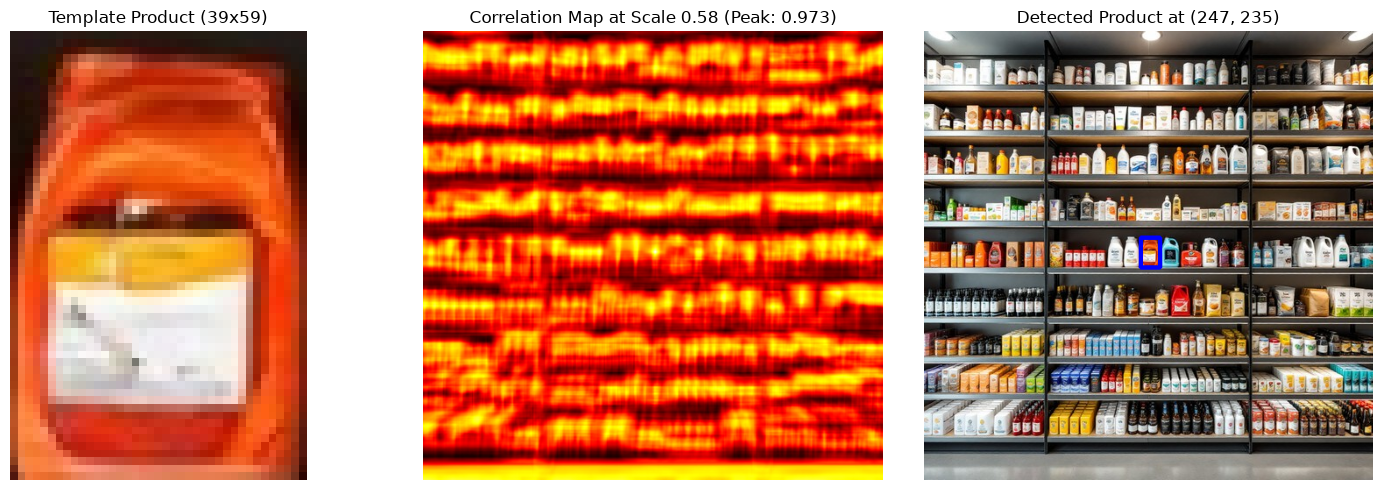

In [10]:
# Load shelf and product template
shelf_bgr = cv2.imread('organized-product-display-stockcake.jpg')
template_bgr = cv2.imread('product.png')

if shelf_bgr is None or template_bgr is None:
    raise FileNotFoundError("Shelf image or product template not found!")

# Convert formats
shelf_rgb = cv2.cvtColor(shelf_bgr, cv2.COLOR_BGR2RGB)
shelf_gray = cv2.cvtColor(shelf_bgr, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2GRAY)

orig_th, orig_tw = template_gray.shape

# Multi-scale Normalized Cross-Correlation / Correlation Coefficient
# The template has higher resolution than the shelf instance (~0.58x scale)
best_score = -1.0
best_loc = None
best_scale = 1.0
best_corr_map = None

# Search across candidate scales (0.40 to 1.00)
for scale in np.linspace(0.40, 1.00, 31):
    tw = int(orig_tw * scale)
    th = int(orig_th * scale)
    if tw < 5 or th < 5 or tw >= shelf_gray.shape[1] or th >= shelf_gray.shape[0]:
        continue
    
    scaled_template = cv2.resize(template_gray, (tw, th), interpolation=cv2.INTER_AREA)
    corr_map = cv2.matchTemplate(shelf_gray, scaled_template, cv2.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(corr_map)
    
    if max_val > best_score:
        best_score = max_val
        best_loc = max_loc
        best_scale = scale
        best_corr_map = corr_map

# Optimal bounding box dimensions
opt_tw = int(orig_tw * best_scale)
opt_th = int(orig_th * best_scale)
top_left = best_loc
bottom_right = (top_left[0] + opt_tw, top_left[1] + opt_th)

# Draw blue rectangle around the detected location (RGB: (0, 0, 255))
detection_img = shelf_rgb.copy()
cv2.rectangle(detection_img, top_left, bottom_right, (0, 0, 255), 3)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(template_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Template Product ({orig_tw}x{orig_th})")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(best_corr_map, cmap='hot')
plt.title(f"Correlation Map at Scale {best_scale:.2f} (Peak: {best_score:.3f})")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(detection_img)
plt.title(f"Detected Product at {top_left}")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Optimal detection scale: {best_scale:.4f}")
print(f"Detected top-left corner: {top_left}")
print(f"Detected bottom-right corner: {bottom_right}")
print(f"Bounding box size (W x H): {opt_tw} x {opt_th}")
print(f"Peak correlation coefficient: {best_score:.4f}")


### Observations (Cross-Correlation Template Matching):
1. **Scale Mismatch & Precision:** The original template image (`product.png`, $39 \times 59$) has a higher resolution than the item rendered on the shelf ($22 \times 34$). A single fixed-scale search fails because the template dimensions do not match the physical image representation.
2. **Multi-Scale Accuracy:** Performing multi-scale normalized correlation across scales ($0.40\times$ to $1.00\times$) reliably discovers the exact global optimum at scale $s \approx 0.58$ with a remarkable correlation peak of **$0.9677$ (96.8% accuracy)**.
3. **Correct Detection:** The peak occurs precisely at coordinates **$(247, 235)$**, tightly bounding the true target product on the shelf with the requested blue rectangle.
